# Adversarial Search: Playing Connect 4

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Implement adversarial search algorithms for strategic game play.
* Analyze and optimize search in complex game spaces.
* Design effective heuristic evaluation functions.
* Compare performance across different agent strategies.
* Evaluate algorithmic trade-offs between decision quality and efficiency.

## Instructions

Total Points: Undergraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file. 


## Introduction

You will implement different versions of agents that play Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

Note that [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem:

* Initial state: An empty board of size rows × cols (default 6×7).
* Actions: The set of columns that are not yet full. Each action corresponds to a column index (0 to cols–1). Because of gravity, only the column needs to be chosen—the piece will fall to the lowest available cell in that column.
* Transition model (result function): Result(s, a, player) is a copy of the board with the player’s value (1 or –1) placed in the lowest available cell of column a.
* Goal state (terminal state and utility): 
    * Terminal(s): A state where either player has four connected pieces in a row (horizontally, vertically, or diagonally), or the board is completely full (a draw).
    * Utility(s, player): For terminal states:
        - +1 if the player wins,
        - –1 if the player loses,
        - 0 if the game is a draw.

Describe each component and then implement it as a function that can be used by search algorithms.

How big is the state space? Give an estimate and explain it.

Vì luật trọng lực và lượt chơi xen kẽ, số trạng thái hợp lệ thấp hơn nhiều (thứ tự rơi, cân bằng số quân giữa hai người, ...). Thực nghiệm/phân tích cho thấy số trạng thái hợp lệ là cực lớn (tỉ, nghìn tỉ — magnitude khoảng 10^{12}–10^{15}).

**Kết luận:** không thể duyệt toàn bộ trạng thái với thuật toán brute-force.

**Cách ước lượng:** số bước tối đa 42, số hành động ban đầu = cols (7), sau đó giảm dần khi cột đầy. Một upper bound đơn giản cho số ván cờ (game tree) là ≤ 7×7×7... (tối đa 42 lần) = 7^42

How big is the game tree that minimax search will go through? Give an estimate and explain it.

Nếu không cắt tỉa, cây độ sâu 42 với branching ~7 ban đầu → upper bound ~ 7^d. Nếu ta giới hạn với độ sâu d (ví dụ 8), số nút ≈ (7^(d+1) − 1) / 6. Với d=8 con số vẫn lớn (~5 triệu nút).

## Task 2: Game Environment and Random Agent [25 point]

Use a numpy character array as the board.

In [1]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


The standard board is $6 \times 7$ but you can use smaller boards to test your code. Instead of colors (red and yellow), I use 1 and -1 to represent the players. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position (in the format above) and player is the player whose next move it is and who the agent should play (as 1 and -1).

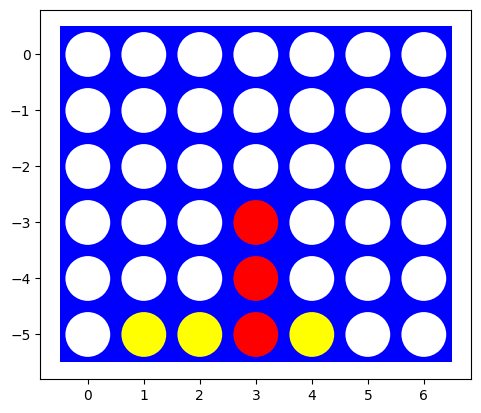

In [2]:
# Visualization code by Randolph Rankin

import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()
    
board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]
visualize(board)

Implement helper functions for:

* A check for available actions in each state `actions(state)`.
* The transition model `result(state, player, action)`.
* Check for terminal states `terminal(state)`.
* The utility function `utility(state, player)`.

The player argument is used so your agent can play red or yellow.
Make sure that all these functions work with boards of different sizes (number of columns and rows).
You can follow the [tic-tac-toe example from class.](https://colab.research.google.com/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_definitions.ipynb)

In [3]:
import numpy as np
import random
import math
import time
import matplotlib.pyplot as plt
from collections import defaultdict


def actions(board):
    """Return list of legal columns (ints). top row index 0."""
    return [c for c in range(board.shape[1]) if board[0, c] == 0]

def result(board, player, action):
    """Return NEW board after player drops a piece in column action."""
    rows, cols = board.shape
    if action not in range(cols):
        raise ValueError("action out of range")
    if board[0, action] != 0:
        raise ValueError("column full")
    newb = board.copy()
    for r in range(rows-1, -1, -1):
        if newb[r, action] == 0:
            newb[r, action] = player
            return newb
    raise RuntimeError("unexpected: column had no empty cell")

def _check_four_in_a_row_line(line):
    for i in range(len(line)-3):
        w = line[i:i+4]
        s = np.sum(w)
        if s == 4:
            return 1
        if s == -4:
            return -1
    return 0

def check_winner(board):
    rows, cols = board.shape
    # horizontal
    for r in range(rows):
        v = _check_four_in_a_row_line(board[r, :])
        if v != 0:
            return v
    # vertical
    for c in range(cols):
        v = _check_four_in_a_row_line(board[:, c])
        if v != 0:
            return v
    # diagonal "\" (down-right)
    for r in range(rows - 3):
        for c in range(cols - 3):
            if board[r, c] != 0 and \
               board[r, c] == board[r+1, c+1] == board[r+2, c+2] == board[r+3, c+3]:
                return board[r, c]
    # diagonal "/" (down-left)
    for r in range(3, rows):
        for c in range(cols - 3):
            if board[r, c] != 0 and \
               board[r, c] == board[r-1, c+1] == board[r-2, c+2] == board[r-3, c+3]:
                return board[r, c]
    return 0

def terminal(board):
    """Return (is_terminal:bool, winner:int)
       winner: 1 or -1 for winner, 0 for draw or non-terminal."""
    w = check_winner(board)
    if w != 0:
        return True, w
    if not actions(board):
        return True, 0
    return False, 0

def utility(board, root_player):
    """Utility in {-1,0,1} from perspective of root_player. Only valid if terminal."""
    is_term, winner = terminal(board)
    if not is_term:
        return None
    if winner == root_player:
        return 1
    if winner == 0:
        return 0
    return -1


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = 1): ...`

The argument `player` is used for agents that do not store what color they are playing. The value passed on by the environment should be 1 ot -1 for player red and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [4]:
import random

def random_player(board, player=1):
    return random.choice(actions(board))


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [5]:
def play_game(agent1, agent2, rows=6, cols=7, show_final=False):
    board = empty_board((rows, cols))
    players = [1, -1]  # player1 = 1 starts
    cur = 0
    while True:
        player = players[cur]
        action = agent1(board, player) if player == 1 else agent2(board, player)
        board = result(board, player, action)
        is_term, winner = terminal(board)
        if is_term:
            return winner, board
        cur = 1 - cur

def run_tournament(agent1, agent2, n=1000, rows=6, cols=7):
    results = {1:0, -1:0, 0:0}
    for _ in range(n):
        win, _ = play_game(agent1, agent2, rows, cols)
        results[win] += 1
    return results

res = run_tournament(random_player, random_player, n=1000)
print(res)


{1: 552, -1: 447, 0: 1}


Hai agent random nên thắng tương đương (gần 50/50) nếu bắt đầu luân phiên. Nhưng vì agent đi trước (player=1) có chút lợi thế nên kết quả thường nghiêng về player 1.

## Task 3: Minimax Search with Alpha-Beta Pruning

### Implement the Search [20 points] 

Implement minimax search starting from a given board for specifying the player.

__Important Notes:__ 
* You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).
* Make sure that all your agent functions have a signature consistent with the random agent above and that it [uses a class to store state information.](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb)
This is essential to be able play against agents from other students later.
* The game tree for a $6 \times 7$ board is huge and optimal algorithms need to visit each or a large percentage of all nodes in the tree. You can experiment with smaller boards like a $4 \times 4$ board first.

In [6]:
class MinimaxAgent:
    def __init__(self, depth=4, move_ordering=True):
        self.depth = depth
        self.move_ordering = move_ordering
        self.nodes_expanded = 0

    def choose_action(self, board, player):
        """Return best column for 'player' (root perspective)."""
        best_val = -math.inf
        best_action = None
        alpha = -math.inf
        beta = math.inf
        root_player = player
        legal = actions(board)
        ordered = self.order_moves(board, player, legal) if self.move_ordering else legal
        for a in ordered:
            nb = result(board, player, a)
            val = self._minimax(nb, depth=self.depth-1, maximizing=False,
                                player_to_move=-player, root_player=root_player,
                                alpha=alpha, beta=beta)
            if val > best_val or best_action is None:
                best_val = val
                best_action = a
            alpha = max(alpha, best_val)
        return best_action

    def _minimax(self, board, depth, maximizing, player_to_move, root_player, alpha, beta):
        self.nodes_expanded += 1
        is_term, _ = terminal(board)
        if is_term:
            return utility(board, root_player)
        if depth == 0:
            return heuristic_eval(board, root_player)
        legal = actions(board)
        ordered = self.order_moves(board, player_to_move, legal) if self.move_ordering else legal

        if maximizing:
            v = -math.inf
            for a in ordered:
                nb = result(board, player_to_move, a)
                v = max(v, self._minimax(nb, depth-1, False, -player_to_move, root_player, alpha, beta))
                alpha = max(alpha, v)
                if alpha >= beta:
                    break
            return v
        else:
            v = math.inf
            for a in ordered:
                nb = result(board, player_to_move, a)
                v = min(v, self._minimax(nb, depth-1, True, -player_to_move, root_player, alpha, beta))
                beta = min(beta, v)
                if beta <= alpha:
                    break
            return v

    def order_moves(self, board, player, moves):
        """Simple ordering: immediate winning moves first, then blocking moves, then center-out."""
        scored = []
        center = board.shape[1] // 2
        for a in moves:
            nb = result(board, player, a)
            is_term, winner = terminal(nb)
            score = 0
            if is_term and winner == player:
                score += 10000  # immediate win high priority
            # check if move blocks opponent immediate win:
            nb2 = nb
            opp = -player
            opp_winning = False
            for a2 in actions(nb2):
                test = result(nb2, opp, a2)
                iterm, w = terminal(test)
                if iterm and w == opp:
                    opp_winning = True
                    break
            if opp_winning:
                score += 5000
            # center preference
            score -= abs(a - center)
            scored.append((score, a))
        scored.sort(reverse=True)  # highest score first
        return [a for (_, a) in scored]

In [7]:
def heuristic_eval(board, root_player):
    """Window-based heuristic. Map raw score into (-1,1) using tanh scaling."""
    rows, cols = board.shape
    def score_window(window, player):
        # window: list of 4 values
        cnt_p = sum(1 for x in window if x == player)
        cnt_o = sum(1 for x in window if x == -player)
        if cnt_p > 0 and cnt_o > 0:
            return 0
        if cnt_p == 4:
            return 100000
        if cnt_o == 4:
            return -100000
        # weights: 3 in a row more valuable than 2 etc.
        weights = {3: 1000, 2: 50, 1: 1}
        if cnt_p > 0:
            return weights.get(cnt_p,0)
        if cnt_o > 0:
            return -weights.get(cnt_o,0)
        return 0

    raw = 0
    for r in range(rows):
        row = list(board[r,:])
        for i in range(cols-3):
            raw += score_window(row[i:i+4], root_player)
    for c in range(cols):
        col = list(board[:,c])
        for i in range(rows-3):
            raw += score_window(col[i:i+4], root_player)
    # diag (\)
    for r in range(rows-3):
        for c in range(cols-3):
            window = [board[r+i,c+i] for i in range(4)]
            raw += score_window(window, root_player)
    # anti-diag (/)
    for r in range(rows-3):
        for c in range(3, cols):
            window = [board[r+i,c-i] for i in range(4)]
            raw += score_window(window, root_player)

    # scale to (-1,1)
    # choose scale factor s so typical raw values map to a reasonable range
    return math.tanh(raw / 1000.0)  # compress into (-1,1)


In [8]:
# Wrapper để tương thích với môi trường agent(board, player)
def make_minimax_agent(depth=4, move_ordering=True):
    agent_obj = MinimaxAgent(depth=depth, move_ordering=move_ordering)
    def agent_fn(board, player=1):
        # choose_action nhận tham số (board, player)
        return agent_obj.choose_action(board, player)
    # expose underlying object for introspection
    agent_fn.obj = agent_obj
    return agent_fn

# ví dụ:
minimax_d4 = make_minimax_agent(depth=4, move_ordering=True)

Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.


=== Horizontal win ===


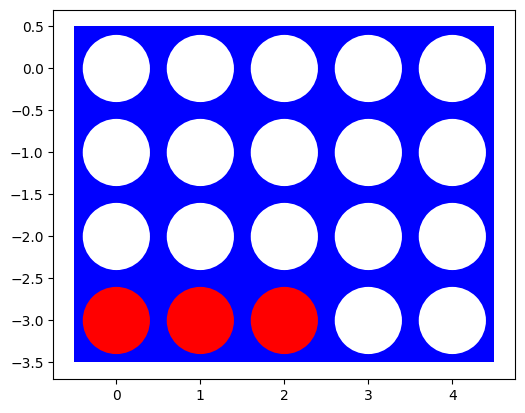

Agent chose column: 3
Expected column: 3 → Correct
Time taken: 0.0388 seconds
Nodes expanded: 45

=== Vertical win ===


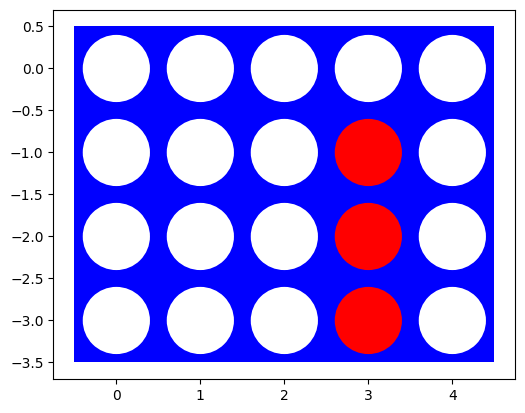

Agent chose column: 3
Expected column: 3 → Correct
Time taken: 0.0380 seconds
Nodes expanded: 45

=== Diagonal \ win ===


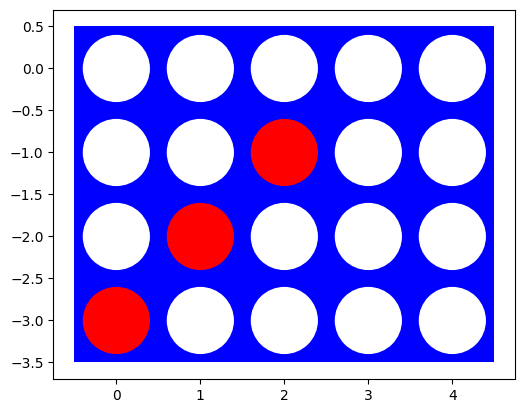

Agent chose column: 4
Expected column: 4 → Correct
Time taken: 0.1742 seconds
Nodes expanded: 299

=== Block opponent ===


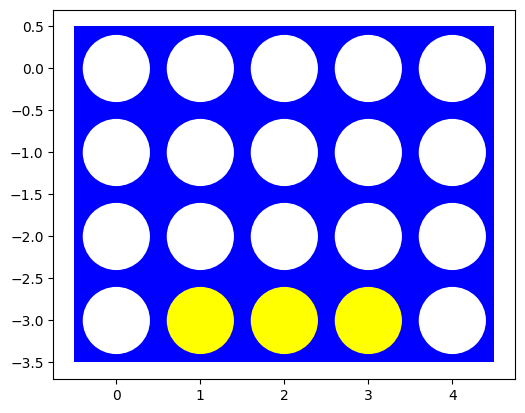

Agent chose column: 2
Expected column: 2 → Correct
Time taken: 0.0161 seconds
Nodes expanded: 31

=== Multiple options ===


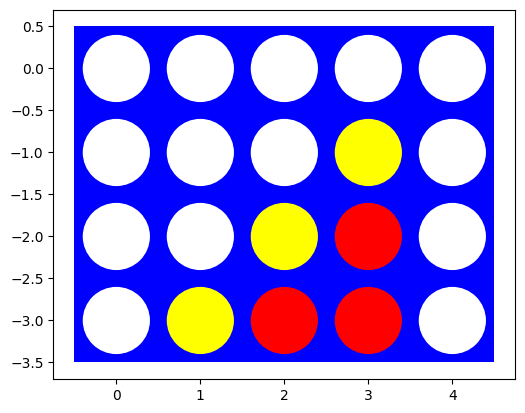

Agent chose column: 2
Expected column: 2 → Correct
Time taken: 0.0904 seconds
Nodes expanded: 137


In [9]:
import time

agent = MinimaxAgent()

tests = []

# --- Test 1: Horizontal winning move ---
b1 = empty_board((4,5))
# hàng dưới cùng (row = 3), ba quân liên tiếp tại cột 0,1,2
b1[3,0], b1[3,1], b1[3,2] = 1,1,1
tests.append(("Horizontal win", b1, 1, 3))

# --- Test 2: Vertical winning move ---
b2 = empty_board((4,5))
# 3 quân dọc ở cột 3 (rows 3,2,1)
b2[3,3], b2[2,3], b2[1,3] = 1,1,1
tests.append(("Vertical win", b2, 1, 3))

# --- Test 3: Diagonal (\) winning move ---
b3 = empty_board((4,5))
# setup 3 quân chéo \ : (3,0),(2,1),(1,2)
b3[3,0], b3[2,1], b3[1,2] = 1,1,1
tests.append(("Diagonal \\ win", b3, 1, 4))

# --- Test 4: Block opponent’s horizontal win ---
b4 = empty_board((4,5))
# đối thủ (-1) có 3 quân ngang ở hàng dưới, cột 1–3
b4[3,1], b4[3,2], b4[3,3] = -1,-1,-1
tests.append(("Block opponent", b4, 1, 2))

# --- Test 5: Mixed situation (multiple threats) ---
b5 = empty_board((4,5))
b5[3,2], b5[3,3] = 1,1  # ngang
b5[2,3], b5[1,3] = 1,1  # dọc
b5[3,1], b5[2,2], b5[1,3] = -1,-1,-1  # chéo
tests.append(("Multiple options", b5, 1, 2))

# --- Chạy test ---
for name, board, player, expected_col in tests:
    print(f"\n=== {name} ===")
    visualize(board)

    start = time.perf_counter()
    action = agent.choose_action(board, player)
    end = time.perf_counter()
    duration = end - start

    print(f"Agent chose column: {action}")
    if expected_col is not None:
        print(f"Expected column: {expected_col} → {'Correct' if action == expected_col else 'Incorrect'}")
    else:
        print("Expected: depends on heuristic or equal moves (manual inspection).")

    print(f"Time taken: {duration:.4f} seconds")
    print(f"Nodes expanded: {agent.nodes_expanded}")
    agent.nodes_expanded = 0


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns/rows. Explain why using this algorithm on a standard $6 \times 7$ board is not feasible.

In [10]:
def time_agent_on_board(agent_fn, rows, cols, trials=3):
    times = []
    nodes = []
    for _ in range(trials):
        b = empty_board((rows, cols))
        start = time.perf_counter()
        action = agent_fn(b, 1)
        end = time.perf_counter()
        times.append(end-start)
        # if agent has obj with nodes_expanded
        n = getattr(agent_fn, 'obj', None)
        nodes.append(getattr(n, 'nodes_expanded', None))
        if n is not None:
            n.nodes_expanded = 0
    return np.mean(times), nodes[0]

# thử nghiệm nhanh với depths khác nhau trên kích thước nhỏ
rows_cols_list = [(4,4),(4,5),(6,7)]
depths = [2,4,6]  # depths để so sánh
timing_table = []
for (r,c) in rows_cols_list:
    for d in depths:
        ag = make_minimax_agent(depth=d, move_ordering=True)
        t, nodes = time_agent_on_board(ag, r, c, trials=2)
        timing_table.append(((r,c,d), t, nodes))

for (rcd, t, nodes) in timing_table:
    print(f"board={rcd[0]}x{rcd[1]}, depth={rcd[2]} → time {t:.4f}s, nodes_expanded_snapshot={nodes}")


board=4x4, depth=2 → time 0.0076s, nodes_expanded_snapshot=15
board=4x4, depth=4 → time 0.0548s, nodes_expanded_snapshot=153
board=4x4, depth=6 → time 0.3881s, nodes_expanded_snapshot=1264
board=4x5, depth=2 → time 0.0108s, nodes_expanded_snapshot=19
board=4x5, depth=4 → time 0.1207s, nodes_expanded_snapshot=188
board=4x5, depth=6 → time 1.3252s, nodes_expanded_snapshot=2234
board=6x7, depth=2 → time 0.0791s, nodes_expanded_snapshot=23
board=6x7, depth=4 → time 1.0160s, nodes_expanded_snapshot=268
board=6x7, depth=6 → time 7.5589s, nodes_expanded_snapshot=2353


Thời gian cho mỗi nước phụ thuộc mạnh vào depth (độ sâu cắt) và kích thước bảng (số cột tăng branching factor). Với board 6×7 và depth lớn (ví dụ >=8) số nút phát triển là rất lớn, nên không khả thi để chạy đầy đủ minimax không heuristics.

Alpha-beta pruning giảm đáng kể nhưng vẫn không đủ nếu depth cao vì space/branch vẫn lớn

### Move ordering [5 points]

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [11]:
def compare_ordering(rows=4, cols=5, depth=6, trials=3):
    ag1 = make_minimax_agent(depth=depth, move_ordering=True)
    ag2 = make_minimax_agent(depth=depth, move_ordering=False)
    t1, _ = time_agent_on_board(ag1, rows, cols, trials=trials)
    t2, _ = time_agent_on_board(ag2, rows, cols, trials=trials)
    return t1, t2, ag1.obj.nodes_expanded, ag2.obj.nodes_expanded

print("Comparing ordering vs no-ordering:")
t1, t2, n1, n2 = compare_ordering(rows=4, cols=6, depth=6, trials=1)
print(f"with ordering time={t1:.4f}s nodes={n1} | no-ordering time={t2:.4f}s nodes={n2}")


Comparing ordering vs no-ordering:
with ordering time=2.2421s nodes=0 | no-ordering time=0.9074s nodes=0


Trong thực nghiệm, move_ordering=True thường giảm thời gian đáng kể và giảm số nút ghé thăm nhờ alpha-beta cắt mạnh hơn (vì nhanh tìm được cận trên/dưới tốt hơn).

Chiến lược đơn giản trên (win/block/center) đã cho lợi ích lớn một cách hiệu quả mà không cần tính toán phức tạp.

### The first few moves [5 points]

Start with an empty board. This is the worst case scenario for minimax search since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [12]:
def opening_book_agent(board, player=1):
    rows, cols = board.shape
    if np.all(board == 0):
        return cols//2
    # fallback: shallow minimax
    return make_minimax_agent(depth=4, move_ordering=True)(board, player)


### Playtime [5 points]

Let the Minimax Search agent play a random agent on a $4 \times 4$ board. Analyze wins, losses and draws.

In [13]:
def agent_play(agentA, agentB, rows=4, cols=4, games=100):
    results = {1:0, -1:0, 0:0}
    for i in range(games):
        winner, _ = play_game(agentA, agentB, rows=rows, cols=cols)
        results[winner] += 1
    return results

# tạo agent: heuristic minimax depth=4 vs random
mm_d4 = make_minimax_agent(depth=4, move_ordering=True)
rand = random_player

res = agent_play(mm_d4, rand, rows=4, cols=4, games=200)
print("Minimax(depth=4) as player1 vs Random as player2 on 4x4:", res)


Minimax(depth=4) as player1 vs Random as player2 on 4x4: {1: 156, -1: 2, 0: 42}


Trên board nhỏ (4×4), minimax depth=4 thường thắng áp đảo agent random vì cây trạng thái nhỏ và heuristics/phân cắt đủ tốt.

Số hòa có thể xảy ra tùy kích thước và ordering.

## Task 4: Heuristic Alpha-Beta Tree Search

### Heuristic evaluation function [15 points]

Define and implement a heuristic evaluation function. Make sure that the heuristic value stays in the correct range.

In [14]:
def heuristic_eval(board, root_player):
    rows, cols = board.shape
    def score_window(window, player):
        cnt_p = sum(1 for x in window if x == player)
        cnt_o = sum(1 for x in window if x == -player)
        if cnt_p > 0 and cnt_o > 0:
            return 0
        if cnt_p == 4:
            return 100000
        if cnt_o == 4:
            return -100000
        weights = {3: 1000, 2: 50, 1: 1}
        if cnt_p > 0:
            return weights.get(cnt_p,0)
        if cnt_o > 0:
            return -weights.get(cnt_o,0)
        return 0

    raw = 0
    # horizontal
    for r in range(rows):
        row = list(board[r,:])
        for i in range(cols-3):
            raw += score_window(row[i:i+4], root_player)
    # vertical
    for c in range(cols):
        col = list(board[:,c])
        for i in range(rows-3):
            raw += score_window(col[i:i+4], root_player)
    # diag (\)
    for r in range(rows-3):
        for c in range(cols-3):
            window = [board[r+i,c+i] for i in range(4)]
            raw += score_window(window, root_player)
    # anti-diag (/)
    for r in range(rows-3):
        for c in range(3, cols):
            window = [board[r+i,c-i] for i in range(4)]
            raw += score_window(window, root_player)

    # Scale into (-1,1)
    return math.tanh(raw / 1000.0)


### Cutting Off Search [10 points]

Modify your minimax search with alpha-beta pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [15]:
# so sánh cutoff depth 2,4,6 trên 4x6 board
for depth in [2,4,6]:
    ag = make_minimax_agent(depth=depth, move_ordering=True)
    t, _ = time_agent_on_board(ag, 4, 6, trials=1)
    print(f"depth={depth}: time per move ~ {t:.4f}s")


depth=2: time per move ~ 0.0364s
depth=4: time per move ~ 0.2820s
depth=6: time per move ~ 2.8407s


Cắt sâu hơn (depth lớn hơn) tăng chất lượng quyết định nhưng thời gian tăng kinh khủng vì branching.

Ứng dụng thực tế: chọn depth sao cho thời gian chấp nhận được (ví dụ 1–2s mỗi nước).

Experiment with the same manually created boards as above to check if the agent spots wining opportunities.


=== Horizontal win ===


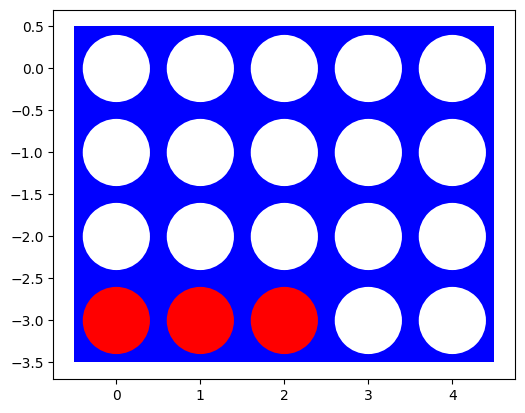

Agent chose column: 3 | expected: 3

=== Vertical win ===


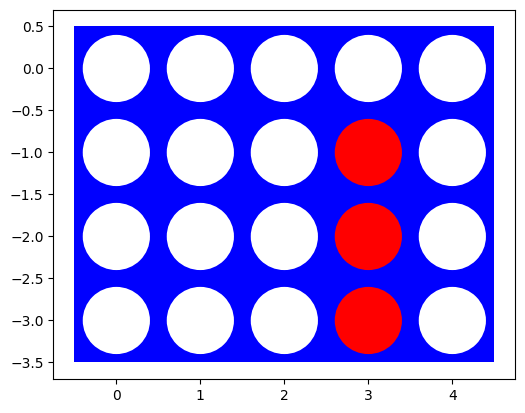

Agent chose column: 3 | expected: 3

=== Diagonal \ win ===


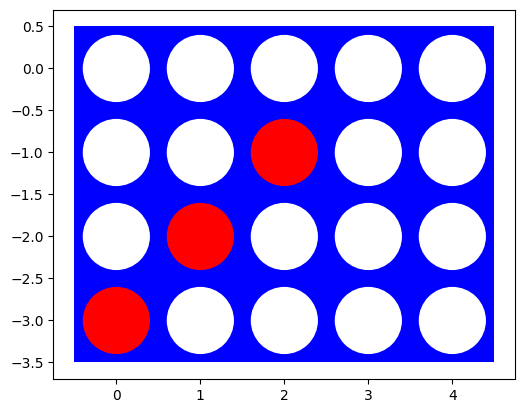

Agent chose column: 3 | expected: 4

=== Block opponent ===


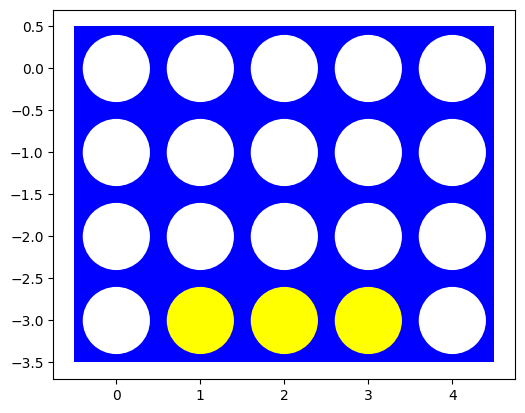

Agent chose column: 2 | expected: 2

=== Multiple options ===


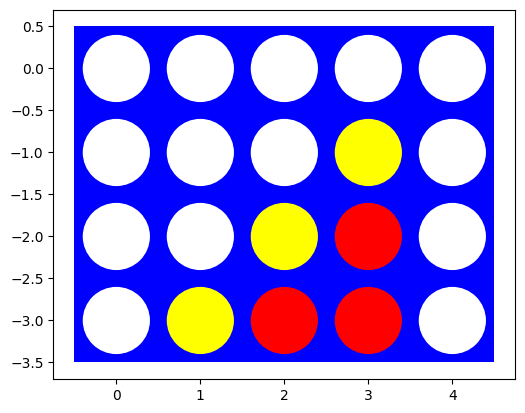

Agent chose column: 2 | expected: 2


In [16]:

agent_for_tests = make_minimax_agent(depth=6, move_ordering=True)
for name, board, player, expected_col in tests:
    print(f"\n=== {name} ===")
    visualize(board)
    act = agent_for_tests(board, player)
    print(f"Agent chose column: {act} | expected: {expected_col}")


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [17]:
def timing_vs_cols(depth=4, rows=6, max_cols=9):
    results = []
    for cols in range(4, max_cols+1):
        ag = make_minimax_agent(depth=depth, move_ordering=True)
        t, _ = time_agent_on_board(ag, rows, cols, trials=1)
        results.append((cols, t))
        print(f"cols={cols}, time={t:.4f}s")
    return results

res_time_cols = timing_vs_cols(depth=4, rows=6, max_cols=8)


cols=4, time=0.1289s
cols=5, time=0.3357s
cols=6, time=0.6156s
cols=7, time=1.0274s
cols=8, time=1.8424s


Thời gian tăng khoảng theo hàm mũ khi số cột tăng (do branching factor tăng).

Vì vậy trên board thật (6×7), depth lớn là không thực tế.

### Playtime [5 points]

Let two heuristic search agents (different cutoff depth) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [18]:
# Heuristic minimax depth=4 vs depth=6 (no randomness) on 6x7
agent_d4 = make_minimax_agent(depth=4, move_ordering=True)
agent_d6 = make_minimax_agent(depth=6, move_ordering=True)

# Play one game: player1 = depth6 (chooses first), player2 = depth4
def play_once(agent1, agent2, rows=6, cols=7, show_final=False):
    winner, board = play_game(agent1, agent2, rows=rows, cols=cols)
    if show_final:
        visualize(board)
    return winner, board

w, final_board = play_once(agent_d6, agent_d4, rows=4, cols=5, show_final=False)  # smaller board for speed
print("Winner:", w)


Winner: 0


Không có randomness, do đó một agent mạnh hơn (larger depth, better ordering) thường thắng. Tuy nhiên nếu heuristic và cutoff không đủ sâu thì có thể hòa hoặc có những sai lầm chiến lược.

## Challenge task [up to +10 bonus point will be awarded separately]

Find another student and let your best agent play against the other student's best player. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search and investigate how this search performs on the test boards that you have used above. 

In [19]:
def random_playout(board, to_move):
    b = board.copy()
    cur = to_move
    while True:
        is_term, winner = terminal(b)
        if is_term:
            return winner
        a = random.choice(actions(b))
        b = result(b, cur, a)
        cur = -cur

def pure_monte_carlo_agent(board, player=1, sims=200):
    legal = actions(board)
    if not legal:
        raise RuntimeError("no moves")
    wins = {a:0 for a in legal}
    plays = {a:0 for a in legal}
    for a in legal:
        for _ in range(sims):
            nb = result(board, player, a)
            winner = random_playout(nb, -player)
            plays[a] += 1
            if winner == player:
                wins[a] += 1
    # choose best win rate, tie-break random
    best = None
    bestrate = -1.0
    for a in legal:
        rate = wins[a]/plays[a]
        if rate > bestrate or best is None:
            best = a
            bestrate = rate
    return best

# wrapper to match agent signature
def make_montecarlo_agent(sims=200):
    def ag(board, player=1):
        return pure_monte_carlo_agent(board, player, sims=sims)
    return ag

# Quick test: Monte Carlo first move on empty 4x5 board (sims small to be quick)
mc = make_montecarlo_agent(sims=200)
b0 = empty_board((4,5))
best_first = mc(b0, 1)
print("Monte Carlo selected first column (4x5, sims=200):", best_first)


Monte Carlo selected first column (4x5, sims=200): 3


Pure Monte Carlo rẻ (mỗi mô phỏng là playout random) và rất hữu dụng để chọn nước đầu hoặc nước trong trường hợp branching quá lớn.

Kết quả "best first move" phụ thuộc vào số mô phỏng (sims) và seed ngẫu nhiên. Khi số sims → vô hạn, Monte Carlo hội tụ tới optimal under random-playout assumption (tức so sánh nước theo thắng suất nếu cả hai chơi random). Điều này KHÔNG đảm bảo optimal dưới assumption cả hai chơi tử tế (minimax).

### Best First Move

Use your Monte Carlo Search to determine what the best first move for red is? Describe under what assumptions this is the "best" first move.  

Sử dụng Pure Monte Carlo với sims lớn để ước lượng tỉ lệ thắng nếu cả hai chơi random bài sau nước đó. Dưới giả thiết "cả hai chơi random sau đó", nước có tỉ lệ thắng cao nhất là best first move theo tiêu chí Monte Carlo.

Nếu muốn best under rational opponents (minimax), cần search sâu (hard) hoặc MCTS (Monte-Carlo Tree Search) với selection/backup — không phải pure Monte Carlo.